In [1]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms
import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

import time

lib_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Code'
os.chdir(lib_dir)
print('library directory: ' + lib_dir)
from modules.networks_clf import *
from modules.signal import spectro_norm, lfp_spectro
from modules.data import *
from modules.metrics import accu_fun

library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code


In [2]:
# @title Load device
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

!nvidia-smi -L


/bin/bash: line 1: nvidia-smi: command not found


In [3]:
# Set the signal parameters
spectro_args = {
    'nfft':800,
    'power':1,
    'LFP_bound':[0, 500],
    'MUA_bound':[500, 2000],
    'spectro_img':[224, 28],
    'LFP_img':[56 * 4, 28],
    'MUA_img':[0, 28],
    'sampling_lfp':2500,
    'sampling_mua':5000,
    'Log':False,
}

dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
acronym_list = acronym_list_gen(dict_dir)

In [4]:
def iter_gen(train_ind, valid_ind, test_ind, brain_signal_lfp, brain_region_index0, coordinate_list):

    data_test = TensorDataset(brain_signal_lfp[test_ind,:], brain_region_index0[test_ind], coordinate_list[test_ind])

    test_iter = DataLoader(data_test, batch_size=128, shuffle=True)

    return test_iter

In [5]:
def iter_subject_gen(train_ind, valid_ind, test_ind, test_subject_ind, brain_signal_lfp, brain_region_index0, coordinate_list):

    test_ind_od = test_subject_ind

    data_test = TensorDataset(brain_signal_lfp[test_ind_od,:], brain_region_index0[test_ind_od], coordinate_list[test_ind_od])

    test_iter_od = DataLoader(data_test, batch_size=128, shuffle=True)

    return test_iter_od

In [6]:
# @title Load data
key = 'stimOff_times'
file_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project43/Data/dat/completed/'
# torch.save(brain_signal_lfp, '/content/drive/MyDrive/Project/BrainRegionId/Project43/Result/brain_signal_lfp/brain_signal_lfp.pt')
# brain_signal_lfp = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project43/Result/brain_signal_lfp/brain_signal_lfp.pt')
list_dict = torch.load(file_dir + '/list_dict.pt', weights_only=False)
# list_dict_acronym_selec = torch.load(file_dir + '/list_dict_acronym_selec.pt')
brain_region_index = list_dict['brain_region_index']
brain_region_index_Cosmos = list_dict['brain_region_index_Cosmos']
coordinate_list = list_dict['coordinate_list']
community_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/community_dict.pt', weights_only=False)
acronym_communities_accu_div = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/acronym_communities_accu_indiv.pt', weights_only=False)


In [ ]:
acronym_communities_accu_div[1.0]

,acu_test,model_type,acronym_test,acronym_index_test
0,0.700000,AnyNet,FRP1,FRP1
1,0.900000,ViT,FRP1,FRP1
2,0.800000,RNN,FRP1,FRP1
3,0.593750,AnyNet,FRP2/3,FRP2/3
4,0.588235,AnyNet,FRP2/3,FRP2/3
...,...,...,...,...
4500,0.958333,AnyNet,FL,FL
4501,0.953125,ViT,FL,FL
4502,0.902778,ViT,FL,FL
4503,0.929688,RNN,FL,FL


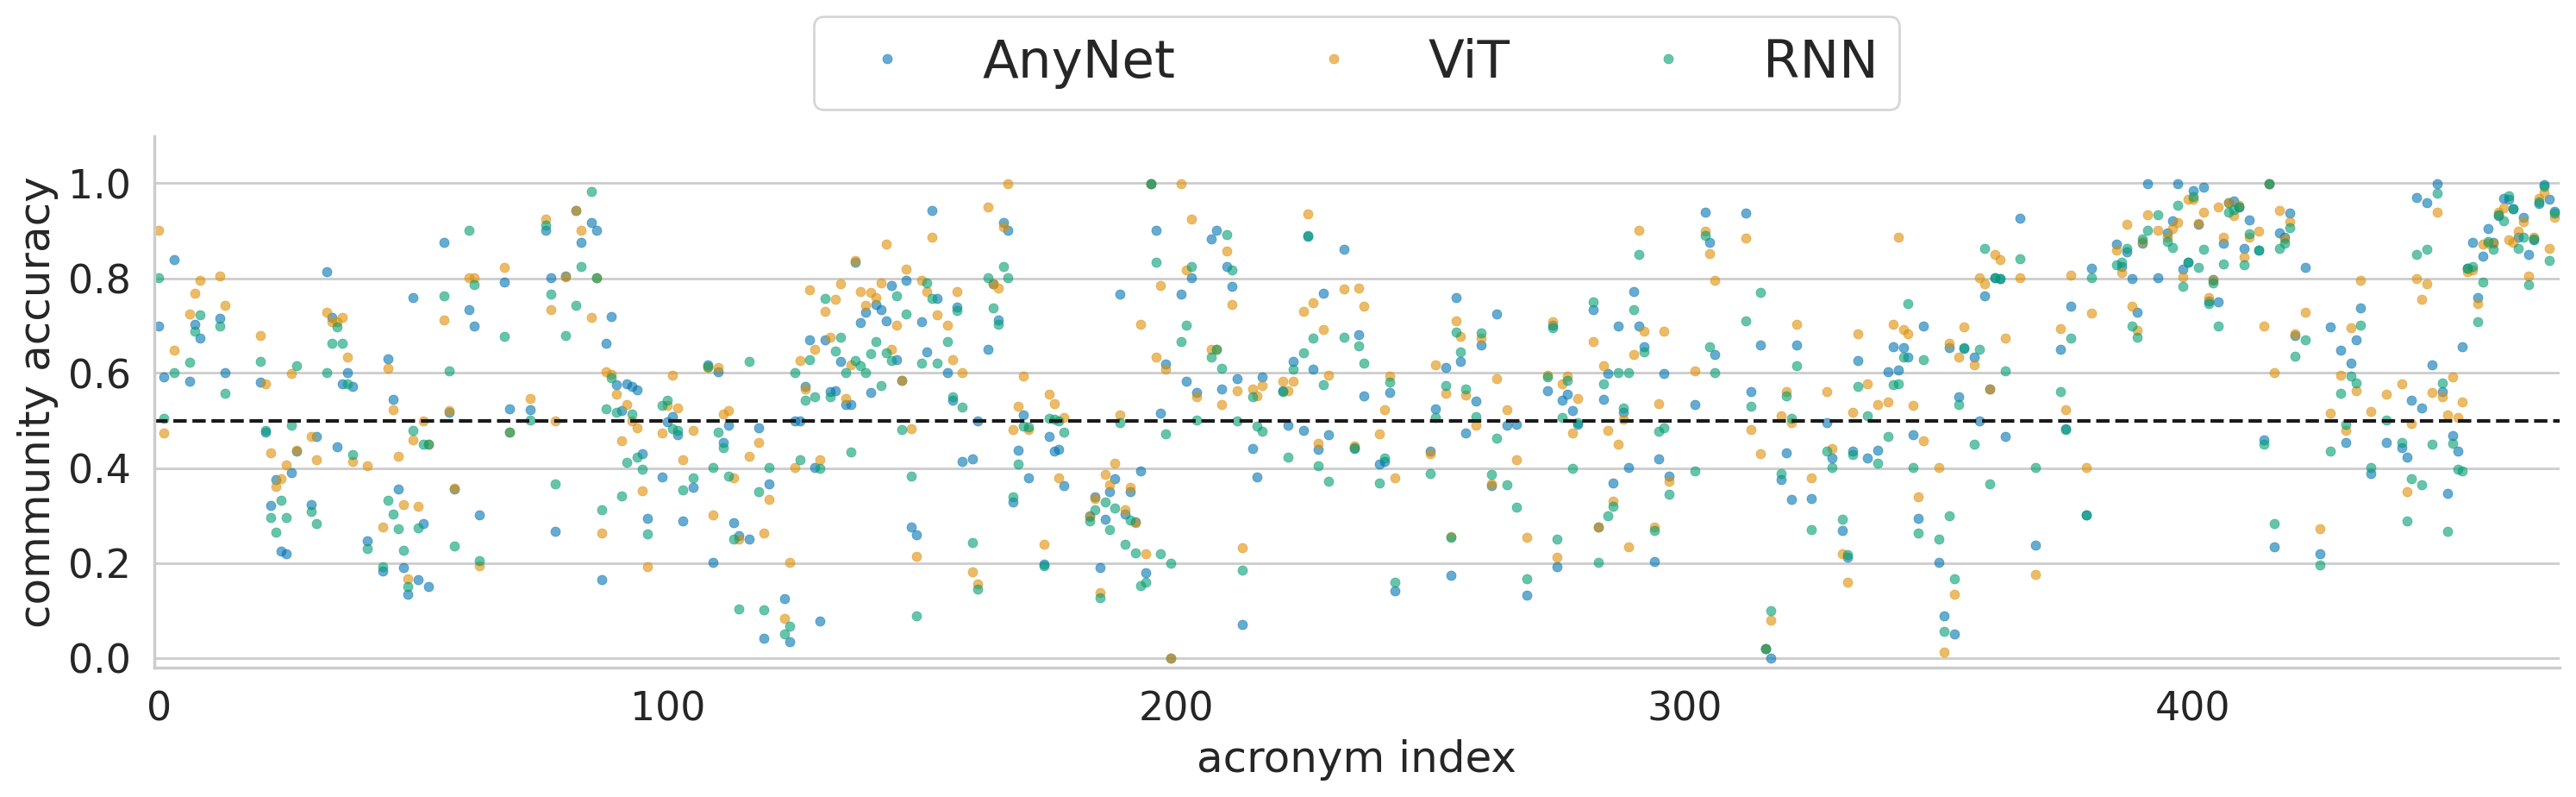

In [ ]:
sns.set_theme(style='whitegrid', font_scale=1.5)
plt.figure(figsize=(18, 4), dpi=200)
# g = sns.FacetGrid(data=acu_test, row='model_type')
g = sns.pointplot(data=acronym_communities_accu_div[1.0], x='acronym_index_test', y='acu_test', hue='model_type',linestyles='none', palette='colorblind', errorbar=None, linewidth=0.3, markersize=4, alpha=0.6)
plt.ylabel('community accuracy')
g.set_xlabel('acronym index')
plt.xticks([0, 100, 200, 300, 400, 500], ['0', '100', '200', '300', '400', '500'])
plt.plot([-1, 472], [0.5, 0.5], 'k--')
plt.ylim([-0.02, 1.1])
plt.xlim([-1, 472])
sns.move_legend(g, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=3, title=None, fontsize=22)
sns.despine()
plt.show()

In [7]:
communities_accu_dict_Top = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/communities_accu_Top_resolution10_02.pt', weights_only=False)

In [8]:
Cosmos_accu_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu/Cosmos_dict.pt', weights_only=False)

In [9]:
color_list = sns.color_palette('colorblind')


In [10]:
color_list

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [11]:
def barplot_annotate_brackets(num1, num2, data, center, height, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """
    Annotate barplot with p-values.

    :param num1: number of left bar to put bracket over
    :param num2: number of right bar to put bracket over
    :param data: string to write or number for generating asterixes
    :param center: centers of all bars (like plt.bar() input)
    :param height: heights of all bars (like plt.bar() input)
    :param yerr: yerrs of all bars (like plt.bar() input)
    :param dh: height offset over bar / bar + yerr in axes coordinates (0 to 1)
    :param barh: bar height in axes coordinates (0 to 1)
    :param fs: font size
    :param maxasterix: maximum number of asterixes to write (for very small p-values)
    """

    if type(data) is str:
        text = data
    else:
        # * is p < 0.01
        # ** is p < 0.001
        # *** is p < 0.0001
        # etc.
        text = ''
        p = .01

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    plt.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    plt.text(*mid, text, **kwargs)

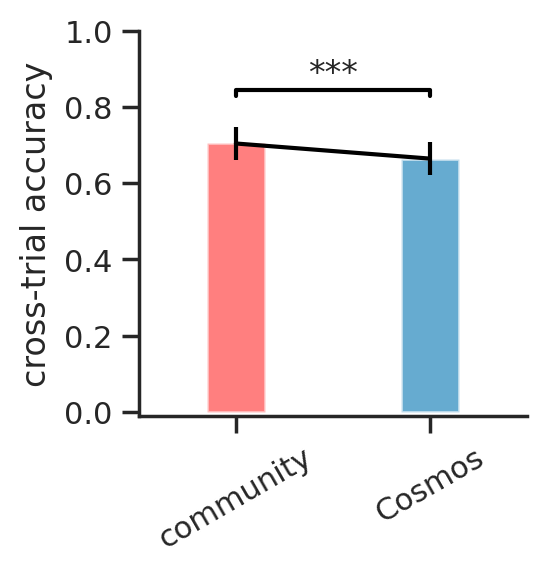

In [16]:
_, p_cca = sp.stats.ttest_ind(np.array(communities_accu_dict_Top[1.0]['cross-trial'][communities_accu_dict_Top[1.0]['cross-trial']['model_type'] == 'AnyNet']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'AnyNet']['acu_test']), equal_var=False)
_, p_ccv = sp.stats.ttest_ind(np.array(communities_accu_dict_Top[1.0]['cross-trial'][communities_accu_dict_Top[1.0]['cross-trial']['model_type'] == 'ViT']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'ViT']['acu_test']), equal_var=False)
_, p_ccr = sp.stats.ttest_ind(np.array(communities_accu_dict_Top[1.0]['cross-trial'][communities_accu_dict_Top[1.0]['cross-trial']['model_type'] == 'RNN']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'RNN']['acu_test']), equal_var=False)

_, p_ccav = sp.stats.ttest_ind(np.array(communities_accu_dict_Top[1.0]['cross-trial'][communities_accu_dict_Top[1.0]['cross-trial']['model_type'] == 'AnyNet']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'ViT']['acu_test']), equal_var=False)
_, p_ccar = sp.stats.ttest_ind(np.array(communities_accu_dict_Top[1.0]['cross-trial'][communities_accu_dict_Top[1.0]['cross-trial']['model_type'] == 'AnyNet']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'RNN']['acu_test']), equal_var=False)

model = 'AnyNet'
sns.set_theme(style='ticks', font_scale=1.0)
plt.figure(figsize=(2.5, 2.5), dpi=200)
plt.bar([1.0], [communities_accu_dict_Top[1.0]['cross-trial'][communities_accu_dict_Top[1.0]['cross-trial']['model_type'] == model]['acu_test'].mean()], width=0.3, color='red', alpha=0.5)

plt.bar([2.0], [Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == model]['acu_test'].mean()], width=0.3, color=color_list[0], alpha=0.6)

plt.errorbar([1.0, 2.0], [communities_accu_dict_Top[1.0]['cross-trial'][communities_accu_dict_Top[1.0]['cross-trial']['model_type'] == model]['acu_test'].mean(),
                Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == model]['acu_test'].mean()], yerr=[communities_accu_dict_Top[1.0]['cross-trial'][communities_accu_dict_Top[1.0]['cross-trial']['model_type'] == model]['acu_test'].std(),
                Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == model]['acu_test'].std()], color='black')

barplot_annotate_brackets(1, 2, p_cca, np.array([1, 1, 2, 2]),
                    [0.75, 0.75, 0.75, 0.75], dh=0.1, barh=.02, maxasterix=3)



# barplot_annotate_brackets(1, 2, p_ccav, np.array([0 - 0.25, 0 - 0.25, 1 + 0.25, 1 + 0.25]),
#             [0.92, 0.92, 0.92, 0.92], dh=0.1, barh=.02, maxasterix=3)
# barplot_annotate_brackets(1, 2, p_ccar, np.array([0 - 0.25, 0 - 0.25, 2 + 0.25, 2 + 0.25]),
#             [1.05, 1.05, 1.05, 1.05], dh=0.1, barh=.02, maxasterix=3)

plt.ylim([-0.01, 1.0])
plt.xticks([1, 2], ['community', 'Cosmos'], rotation=30)
plt.xlim([0.5, 2.5])
plt.ylabel('cross-trial accuracy')

sns.despine()
plt.show()

In [17]:
communities_accu_indiv = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/communities_accu_indiv.pt', weights_only=False)
resolution = 1.0
marked_community = []
for community in np.unique(community_dict[resolution]['communities_label']):
    df_indiv0 = communities_accu_indiv[resolution][communities_accu_indiv[resolution]['acronym_test'] == community]
    for classifier_name in ['AnyNet']:
        if df_indiv0[df_indiv0['model_type'] == classifier_name]['acu_test'].mean() > 0.58:
            marked_community.append(community)

marked_community = np.unique(np.array(marked_community))

In [19]:
################################################################################
import subprocess
import sys
required = {'ONE-api', 'brain', 'ibllib'}
subprocess.check_call([sys.executable, '-m', 'pip', 'install', *required])

from one.api import ONE
from brainbox.io.one import SessionLoader, SpikeSortingLoader

from iblatlas.atlas import AllenAtlas

ba = AllenAtlas()
br = ba.regions
ba.compute_regions_volume()

Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/average_template_25.nrrd Bytes: 32998960


100%|██████████| 31.470260620117188/31.470260620117188 [00:02<00:00, 11.40it/s]


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/annotation_25.nrrd Bytes: 4035363


100%|██████████| 3.848422050476074/3.848422050476074 [00:01<00:00,  2.09it/s]


In [26]:
community_dict[resolution]['communities']

array([366, 380, 385, 386, 387, 388, 389, 390, 391, 393, 395, 396, 397,
       398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410,
       411, 413, 415, 417, 418, 419, 420, 454, 455, 456, 457, 458, 459,
       460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 322,
       345, 369, 374, 375, 379,   3,   6,   7,   8,  12,  13,  33,  34,
        35,  36,  37,  61,  62, 127, 128, 129, 131, 132, 133, 134, 137,
       138, 139, 140, 141, 142, 143, 147, 150, 151, 155, 156, 157, 158,
       163, 164, 165, 166, 167, 226, 227, 236, 237,  99, 100, 101, 102,
       103, 108, 109, 116, 170, 171, 175, 176, 178, 225, 319, 320, 321,
        26,  27,  44,  87, 110, 111, 112, 113, 168, 169, 174, 177, 184,
       435,  22,  23, 105,  20,  21,  56,  57,  93,  94,  95,  96, 118,
       183, 195, 196, 146, 149, 425, 119, 199, 353, 120, 212, 217, 221,
       222, 223, 235, 267, 430, 431, 432, 433, 438,   0,   1, 144, 145,
       152, 153, 207, 208, 228, 422, 443, 209, 210, 211, 125, 24

In [27]:
acronym_list_Cosmos = [br.acronym2acronym(acronym, mapping='Cosmos')[0] for acronym in acronym_list]
acronym_list_Cosmos = np.array(acronym_list_Cosmos)

for community in marked_community:
    ind = np.argwhere(community_dict[resolution]['communities_label'] == community).flatten()
    print('Community:')
    print(community)
    print('Allen:')
    print(community_dict[resolution]['communities_acronym'][ind])
    print('Cosmos:')
    print(acronym_list_Cosmos[community_dict[resolution]['communities'][ind]])


# for community_ii, community in enumerate(communities):
#     print('Community:')
#     print(communities_label[community_ii])
#     print('Allen>>>>>>>>>>>>>>>>>>>>>>>>>')
#     print(np.array(acronym_list)[community])
#     print('Cosmos>>>>>>>>>>>>>>>>>>>>>>>>')
#     print(acronym_list_Cosmos[community])

Community:
0
Allen:
['KF' 'I5' 'DCO' 'VCO' 'CU' 'ECU' 'SPVC' 'SPVI' 'Pa5' 'AMBv' 'GRN' 'ICB'
 'IO' 'IRN' 'LIN' 'LRNm' 'MARN' 'MDRNd' 'MDRNv' 'PARN' 'PAS' 'PGRNd'
 'PGRNl' 'PRP' 'LAV' 'MV' 'SPIV' 'x' 'y' 'FN' 'IP' 'DN' 'VeCB' 'NTS'
 'SPVO' 'LING' 'CENT2' 'CENT3' 'CUL4 5' 'DEC' 'FOTU' 'PYR' 'UVU' 'NOD'
 'SIM' 'ANcr1' 'ANcr2' 'PRM' 'COPY' 'PFL' 'FL']
Cosmos:
['HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB'
 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB' 'HB'
 'HB' 'CB' 'CB' 'CB' 'CB' 'HB' 'HB' 'CB' 'CB' 'CB' 'CB' 'CB' 'CB' 'CB'
 'CB' 'CB' 'CB' 'CB' 'CB' 'CB' 'CB' 'CB' 'CB']
Community:
2
Allen:
['FRP6a' 'MOp5' 'MOp6a' 'MOp6b' 'MOs6a' 'MOs6b' 'SSp-m2/3' 'SSp-m4'
 'SSp-m5' 'SSp-m6a' 'SSp-m6b' 'GU5' 'GU6a' 'ACAd5' 'ACAd6a' 'ACAd6b'
 'ACAv2/3' 'ACAv5' 'ACAv6a' 'ACAv6b' 'PL5' 'PL6a' 'PL6b' 'ILA1' 'ILA2/3'
 'ILA5' 'ILA6a' 'ORBl6a' 'ORBm5' 'ORBm6a' 'ORBvl6a' 'AId5' 'AId6a' 'AId6b'
 'AIp6b' 'AIv2/3' 'AIv5' 'AIv6a' 'AIv6b' 'CLA' 'EPd' 'CP' 'ACB']
Cosmos:
['Is

In [18]:
community_dict[resolution]

{'communities': array([366, 380, 385, 386, 387, 388, 389, 390, 391, 393, 395, 396, 397,
        398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410,
        411, 413, 415, 417, 418, 419, 420, 454, 455, 456, 457, 458, 459,
        460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 322,
        345, 369, 374, 375, 379,   3,   6,   7,   8,  12,  13,  33,  34,
         35,  36,  37,  61,  62, 127, 128, 129, 131, 132, 133, 134, 137,
        138, 139, 140, 141, 142, 143, 147, 150, 151, 155, 156, 157, 158,
        163, 164, 165, 166, 167, 226, 227, 236, 237,  99, 100, 101, 102,
        103, 108, 109, 116, 170, 171, 175, 176, 178, 225, 319, 320, 321,
         26,  27,  44,  87, 110, 111, 112, 113, 168, 169, 174, 177, 184,
        435,  22,  23, 105,  20,  21,  56,  57,  93,  94,  95,  96, 118,
        183, 195, 196, 146, 149, 425, 119, 199, 353, 120, 212, 217, 221,
        222, 223, 235, 267, 430, 431, 432, 433, 438,   0,   1, 144, 145,
        152, 153, 207, 208, 228, 422

/tmp/ipython-input-2300969428.py:4: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.barplot(


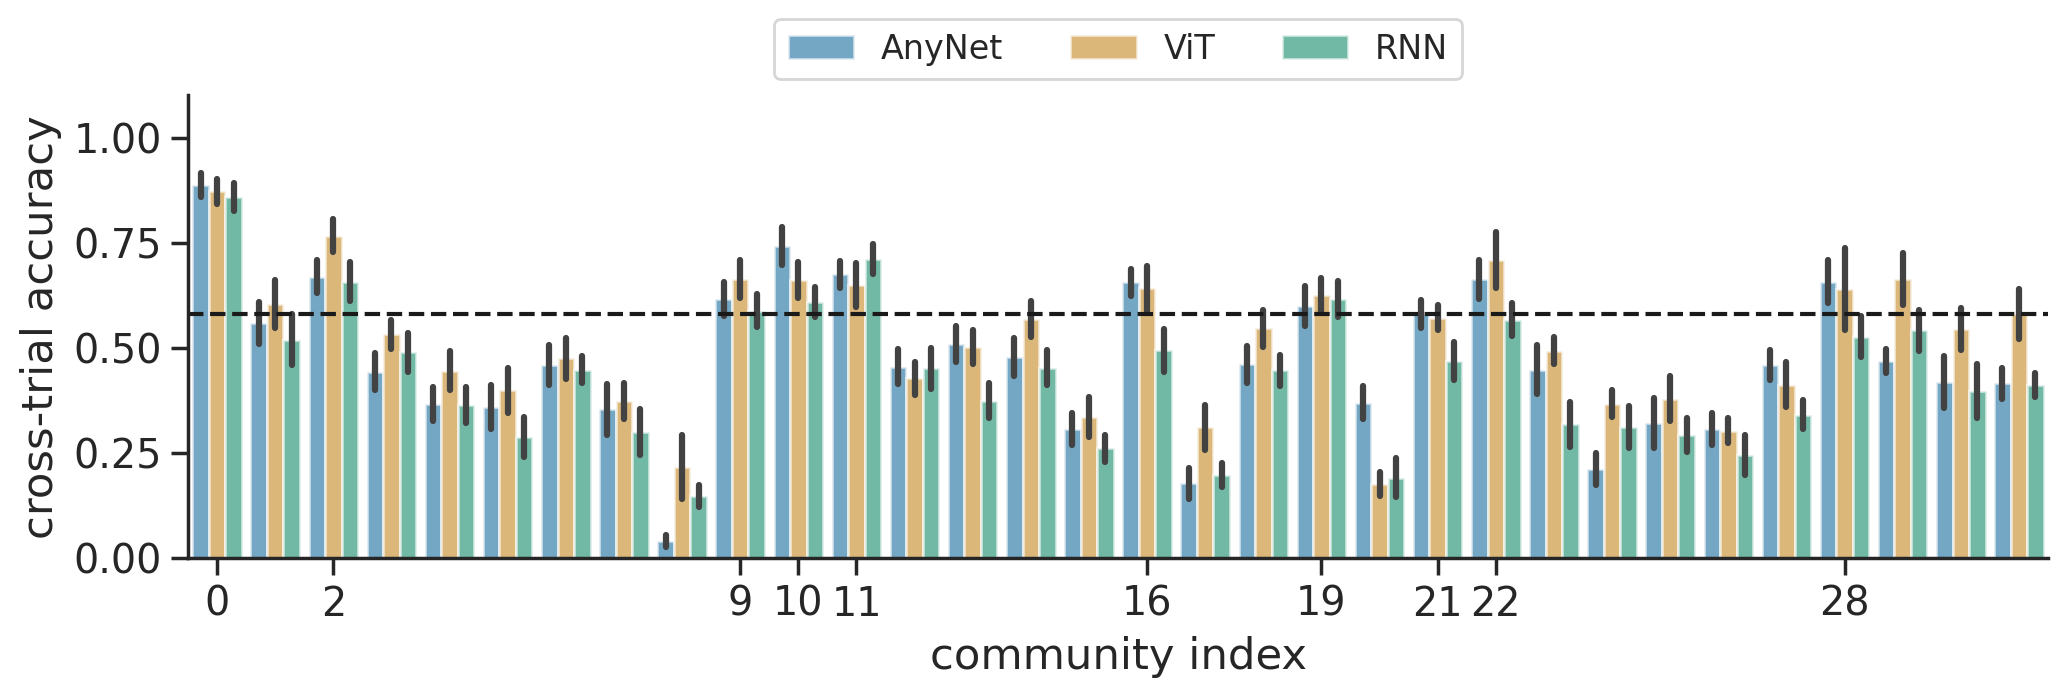

In [28]:
sns.set_theme(style='ticks', font_scale=1.3)
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(12, 3), dpi=200)
g = sns.barplot(
    data=communities_accu_indiv[resolution],
    x='acronym_test', y='acu_test', hue='model_type',
    errorbar='sd', width=0.85, palette=color_list, alpha=.6
)
sns.move_legend(g, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=3, title=None, fontsize=12)
plt.plot([-0.5, 31.5], [0.58, 0.58], 'k--')
plt.xlim([-0.5, 31.5])
plt.ylim([0, 1.1])
plt.xticks(marked_community)
plt.ylabel('cross-trial accuracy')
plt.xlabel('community index')
sns.despine()
# plt.legend(loc='lower left')
plt.show()

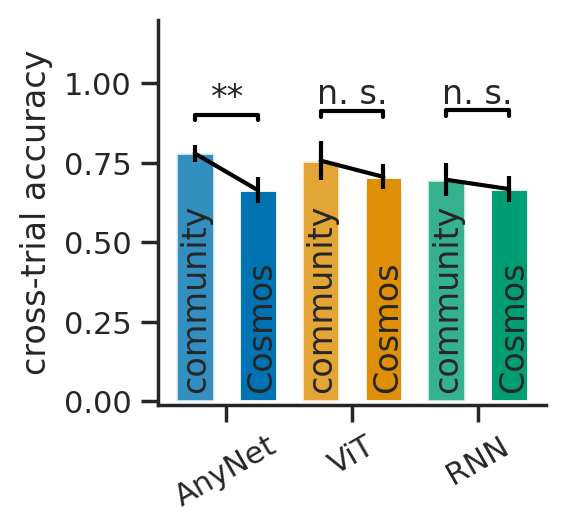

In [ ]:
_, p_cca = sp.stats.ttest_ind(np.array(communities_accu_dict_Top[1.0]['cross-trial'][communities_accu_dict_Top[1.0]['cross-trial']['model_type'] == 'AnyNet']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'AnyNet']['acu_test']), equal_var=False)
_, p_ccv = sp.stats.ttest_ind(np.array(communities_accu_dict_Top[1.0]['cross-trial'][communities_accu_dict_Top[1.0]['cross-trial']['model_type'] == 'ViT']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'ViT']['acu_test']), equal_var=False)
_, p_ccr = sp.stats.ttest_ind(np.array(communities_accu_dict_Top[1.0]['cross-trial'][communities_accu_dict_Top[1.0]['cross-trial']['model_type'] == 'RNN']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'RNN']['acu_test']), equal_var=False)

_, p_ccav = sp.stats.ttest_ind(np.array(communities_accu_dict_Top[1.0]['cross-trial'][communities_accu_dict_Top[1.0]['cross-trial']['model_type'] == 'AnyNet']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'ViT']['acu_test']), equal_var=False)
_, p_ccar = sp.stats.ttest_ind(np.array(communities_accu_dict_Top[1.0]['cross-trial'][communities_accu_dict_Top[1.0]['cross-trial']['model_type'] == 'AnyNet']['acu_test']),
                   np.array(Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == 'RNN']['acu_test']), equal_var=False)


sns.set_theme(style='ticks', font_scale=1.0)
plt.figure(figsize=(2.5, 2.5), dpi=200)
for model_ii, model in enumerate(['AnyNet', 'ViT', 'RNN']):

    plt.bar([model_ii - 0.25], [communities_accu_dict_Top[1.0]['cross-trial'][communities_accu_dict_Top[1.0]['cross-trial']['model_type'] == model]['acu_test'].mean()], width=0.3, color=color_list[model_ii], alpha=0.8)
    plt.text(model_ii - 0.375, 0.05, 'community', rotation=90)
    plt.bar([model_ii + 0.25], [Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == model]['acu_test'].mean()], width=0.3, color=color_list[model_ii])
    plt.text(model_ii + 0.15, 0.05, 'Cosmos', rotation=90)
    plt.errorbar([model_ii - 0.25, model_ii + 0.25], [communities_accu_dict_Top[1.0]['cross-trial'][communities_accu_dict_Top[1.0]['cross-trial']['model_type'] == model]['acu_test'].mean(),
                    Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == model]['acu_test'].mean()], yerr=[communities_accu_dict_Top[1.0]['cross-trial'][communities_accu_dict_Top[1.0]['cross-trial']['model_type'] == model]['acu_test'].std(),
                    Cosmos_accu_dict[Cosmos_accu_dict['model_type'] == model]['acu_test'].std()], color='black')
    if model == 'AnyNet':
        barplot_annotate_brackets(1, 2, p_cca, np.array([model_ii - 0.25, model_ii - 0.25, model_ii + 0.25, model_ii + 0.25]),
                            [0.8, 0.8, 0.7, 0.7], dh=0.1, barh=.02, maxasterix=3)

    if model == 'ViT':
        barplot_annotate_brackets(1, 2, p_ccv, np.array([model_ii - 0.25, model_ii - 0.25, model_ii + 0.25, model_ii + 0.25]),
                    [0.8, 0.8, 0.7, 0.7], dh=0.1, barh=.02, maxasterix=3)

    if model == 'RNN':
        barplot_annotate_brackets(1, 2, p_ccr, np.array([model_ii - 0.25, model_ii - 0.25, model_ii + 0.25, model_ii + 0.25]),
                    [0.8, 0.8, 0.7, 0.7], dh=0.1, barh=.02, maxasterix=3)

# barplot_annotate_brackets(1, 2, p_ccav, np.array([0 - 0.25, 0 - 0.25, 1 + 0.25, 1 + 0.25]),
#             [0.92, 0.92, 0.92, 0.92], dh=0.1, barh=.02, maxasterix=3)
# barplot_annotate_brackets(1, 2, p_ccar, np.array([0 - 0.25, 0 - 0.25, 2 + 0.25, 2 + 0.25]),
#             [1.05, 1.05, 1.05, 1.05], dh=0.1, barh=.02, maxasterix=3)

plt.ylim([-0.01, 1.2])
plt.xticks([0, 1, 2], ['AnyNet', 'ViT', 'RNN'], rotation=30)
plt.ylabel('cross-trial accuracy')

sns.despine()
plt.show()

In [ ]:
p_ccv

np.float64(0.09554973230087015)

In [ ]:
acronym_communities_accu_div = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/acronym_communities_accu_indiv.pt', weights_only=False)
selec_br = []
ig_br = []
for model in ['AnyNet', 'ViT', 'RNN']:
    dict_model = acronym_communities_accu_div[1.0][acronym_communities_accu_div[1.0]['model_type'] == model]
    for acronym in acronym_list:
        if dict_model[dict_model['acronym_test'] == acronym]['acu_test'].mean() < 0.5:
            ig_br.append(acronym)

ig_br = np.unique(np.array(ig_br))
selec_br = np.setdiff1d(np.array(acronym_list), ig_br)

In [ ]:
community_dict[1.0]

In [ ]:
communities_in = []
for acronym_ii, acronym in enumerate(community_dict[1.0]['communities_acronym']):
    if acronym in selec_br:
        communities_in.append(community_dict[1.0]['communities_label'][acronym_ii])
communities_in = np.unique(np.array(communities_in))

In [ ]:
len(communities_in)

20

In [ ]:
communities_accu_indiv = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/communities_accu_indiv.pt', weights_only=False)
marked_community = []
for community in np.unique(community_dict[1.0]['communities_label']):
    df_indiv0 = communities_accu_indiv[1.0][communities_accu_indiv[1.0]['acronym_test'] == community]
    for classifier_name in ['AnyNet', 'ViT', 'RNN']:
        if df_indiv0[df_indiv0['model_type'] == classifier_name]['acu_test'].mean() > 0.60:
            marked_community.append(community)

marked_community = np.unique(np.array(marked_community))

In [ ]:
len(np.intersect1d(communities_in, marked_community))

11

In [ ]:
selec_br = []
for model in ['AnyNet', 'ViT', 'RNN']:
    dict_model = acronym_communities_accu_div[1.0][acronym_communities_accu_div[1.0]['model_type'] == model]
    for acronym in acronym_list:
        if dict_model[dict_model['acronym_test'] == acronym]['acu_test'].mean() >= 0.4:
            selec_br.append(acronym)

selec_br = np.unique(np.array(selec_br))


In [ ]:
len(community_dict[1.0]['communities_acronym'])

338

In [ ]:
len(selec_br)

292

In [ ]:
acronym_communities_accu_div[1.0]['model_type']

,model_type
0,AnyNet
1,ViT
2,RNN
3,AnyNet
4,AnyNet
...,...
4500,AnyNet
4501,ViT
4502,ViT
4503,RNN
